In [6]:
%%html
<style>
/* Any CSS style can go in here. */
.dataframe th {
    font-size: 12px;
}
.dataframe td {
    font-size: 10px;
}
</style>

TypeError: list indices must be integers or slices, not tuple

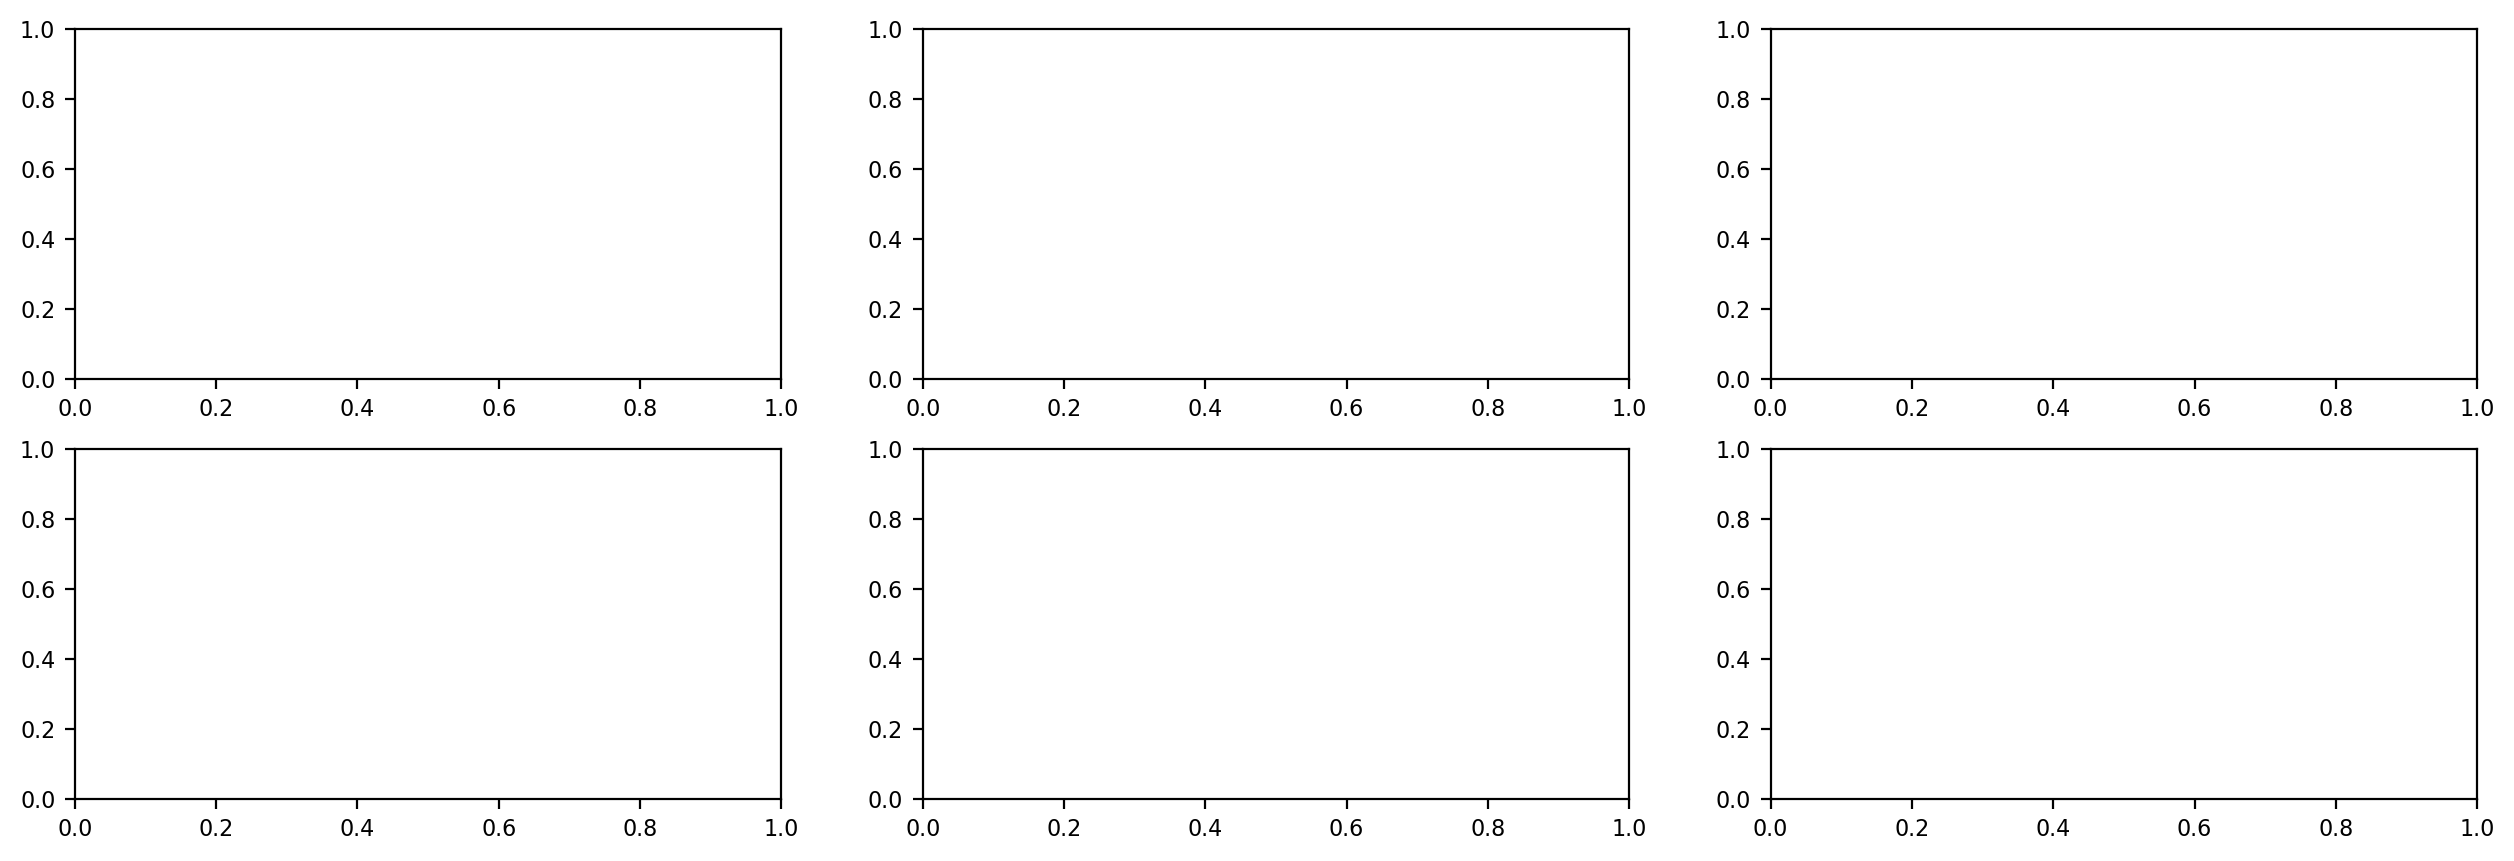

In [7]:
import pandas as pd
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.rcParams["figure.figsize"] = (15.5, 5)
plt.rcParams["font.size"] = 8

number_of_max = 8

check_point_list = [
    "1467250",
    "1475421",
    "3175768",
]

f, axes = plt.subplots(2, len(check_point_list))
axes = np.array(axes).transpose()

for iter_check_point, check_point in enumerate(check_point_list):
    for iter_train_eval, train_eval in enumerate(
        [
            "train",
            "eval"
        ]
    ):
        data_path_list = list(
            Path(
                f"../checkpoints/checkpoint-ccdft_cc-pVDZ_atom-1-{check_point}/loss/"
            ).glob(f"{train_eval}-loss-*")
        )
        data_path_list = sorted(
            data_path_list, key=lambda x: int(x.stem.split("-")[-1])
        )
        max_10_loss = []
        data_name_list = []

        for data_path in data_path_list:
            data_csv = pd.read_csv(data_path)
            if "train_loss_ene" in data_csv.columns:
                data = np.array(data_csv["train_loss_ene"])
            else:
                data = np.array(data_csv["loss_ene"])
            data_name = np.array(data_csv["name"])
            data_argsort = np.argsort(data)[-number_of_max:][::-1]
            if len(max_10_loss) == 0:
                max_10_loss = data[data_argsort]
                data_name_list = [i_mol.split("_cc-pVDZ")[0] for i_mol in data_name[data_argsort]]
            else:
                max_10_loss = np.vstack((max_10_loss, data[data_argsort]))
                data_name_list = np.vstack((data_name_list, [i_mol.split("_cc-pVDZ")[0] for i_mol in data_name[data_argsort]]))

        max_10_loss = max_10_loss[1::2, :]
        data_name_list = data_name_list[1::2, :]
        print(f"check_point: {check_point}, train_eval: {train_eval}")
        df_summary = pd.DataFrame(data_name_list)
        display(df_summary)

        for i in range(number_of_max):
            # print(max_10_loss[:, i])
            axes[iter_check_point, iter_train_eval].plot(
                (max_10_loss[:, i]),
                label=f"max {i+1} loss",
                marker="o",
                markersize=3,
            )
        axes[iter_check_point, iter_train_eval].set_xlabel("iteration")
        axes[iter_check_point, iter_train_eval].set_xlim(-3, 33)
        axes[iter_check_point, iter_train_eval].set_xticks(
            np.linspace(0, 30, 7),
            labels=[f"{int(i*500+250)}" for i in np.linspace(0, 30, 7)],
        )
        axes[iter_check_point, iter_train_eval].set_ylabel(f"max {number_of_max} loss")
        axes[iter_check_point, iter_train_eval].set_ylim(0, 40)
        axes[iter_check_point, iter_train_eval].set_yticks(
            np.linspace(0, 40, 5),
            labels=[f"{int(i)}" for i in np.linspace(0, 40, 5)],
        )
        axes[iter_check_point, iter_train_eval].set_title(
            f"max {number_of_max} {train_eval} loss of {check_point}"
        )

plt.show()
plt.clf()